In [1]:
# base de produtos
from google.colab import files
uploaded = files.upload()

Saving base_produtos_tratada (2).csv to base_produtos_tratada (2).csv


In [2]:
# base de pedidos tratada
from google.colab import files
uploaded = files.upload()

Saving base_pedidos_tratada (1).csv to base_pedidos_tratada (1).csv


In [3]:
# base de familias
from google.colab import files
uploaded = files.upload()

Saving familias.csv to familias.csv


In [65]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [51]:
df_produtos = pd.read_csv('base_produtos_tratada (2).csv', sep=',')
df_pedidos = pd.read_csv('base_pedidos_tratada (1).csv', sep=',')
df_familias = pd.read_csv('familias.csv', sep=';')

# Realizar o cruzamento (Merge)
df_completo = pd.merge(
    df_pedidos,
    df_produtos,
    left_on='orderid',
    right_on='Order',
    how='left'
)

# Limpeza pós-merge
# Como as colunas 'orderid' e 'Order' são idênticas, você pode remover a duplicada
df_completo = df_completo.drop(columns=['Order'])

# Limpeza de espaços e padronização para minúsculas
df_completo['termo_chave'] = df_completo['SKU Name'].astype(str).str.strip().str.split(' ').str[0].str.lower()
df_familias['Product Line_Lower'] = df_familias['Product Line'].astype(str).str.strip().str.lower()

'''
# Exibir os 10 primeiros termos extraídos da base de produtos
print("--- TERMOS CHAVE (Base de Produtos) ---")
print(df_completo['termo_chave'].unique()[:10])

print("\n--- PRODUCT LINE LOWER (Base de Famílias) ---")
# Exibir os 10 primeiros termos da base de famílias
print(df_familias['Product Line_Lower'].unique()[:10])
'''

# Refazer o merge com os termos normalizados
df_final = pd.merge(
    df_completo,
    df_familias,
    left_on='termo_chave',
    right_on='Product Line_Lower',
    how='left'
)

# 1. Renomear a coluna 'termo_chave' para 'familias'
df_final = df_final.rename(columns={'termo_chave': 'familias'})

# 2. Remover as colunas redundantes ou auxiliares
# Nota: Verifique se 'Product Line_Lower' existe antes de dropar para evitar erro
colunas_para_remover = ['Product Line', 'Product Line_Lower']
df_final = df_final.drop(columns=[col for col in colunas_para_remover if col in df_final.columns])

# 3. Visualizar o resultado final
print("Colunas atuais do df_final:")
print(df_final.columns.tolist())
display(df_final.head())

Colunas atuais do df_final:
['orderid', 'status', 'value', 'cli_document', 'tipo_cliente', 'data_tratada', 'pedido_faturado', 'pedido_cancelado', 'numero_compra_cliente', 'recompra', 'data_compra_anterior', 'dias_para_recompra', 'Origin', 'Creation Date', 'Time', 'Client Document', 'UF', 'Status amigável', 'Status', 'Payment Type', 'Payment System Name', 'Payment Value', 'Quantity_SKU', 'ID_SKU', 'SKU Name', 'SKU Value', 'SKU Selling Price', 'SKU Total Price', 'Total Value', 'Discounts Totals', 'Vendedor', 'flag_cancelado', 'Tipo Item', 'flag_desconto_anomalo', 'flag_pagamento_misto', 'Payment Value Tratado', 'Receita Valida', 'Installments Tratado', 'familias']


,orderid,status,value,cli_document,tipo_cliente,data_tratada,pedido_faturado,pedido_cancelado,numero_compra_cliente,recompra,...,Discounts Totals,Vendedor,flag_cancelado,Tipo Item,flag_desconto_anomalo,flag_pagamento_misto,Payment Value Tratado,Receita Valida,Installments Tratado,familias
0,PED_F41193D8,Invoiced,190.42,CLI_000059B4,Novo,2024-11-28,1,0,1.0,0,...,-128.67,Tecnopharma,False,normal,False,False,190.42,190.42,NaN,hyaluage
1,PED_F41193D8,Invoiced,190.42,CLI_000059B4,Novo,2024-11-28,1,0,1.0,0,...,-128.67,Tecnopharma,False,normal,False,False,190.42,190.42,NaN,hyaluage
2,PED_F41193D8,Invoiced,190.42,CLI_000059B4,Novo,2024-11-28,1,0,1.0,0,...,-128.67,Tecnopharma,False,normal,False,False,190.42,190.42,NaN,photoage
3,PED_BFE831E4,Invoiced,177.66,CLI_00020501,Antigo,2023-11-23,1,0,1.0,0,...,-91.94,Tecnopharma,False,normal,False,False,177.66,177.66,NaN,charcoal
4,PED_BFE831E4,Invoiced,177.66,CLI_00020501,Antigo,2023-11-23,1,0,1.0,0,...,-91.94,Tecnopharma,False,normal,False,False,177.66,177.66,NaN,sabonete


In [85]:
# Filtrar apenas pedidos faturados (Remover Canceled, Request-Cancel, etc.)
# Na base de pedidos, o status correto de venda confirmada é 'Invoiced'
df_final = df_final[df_final['status'] == 'Invoiced'].copy()

# Remove itens que não são produtos de venda (amostras/brindes) para que o ticket médio seja puramente de faturamento
df_final = df_final[~df_final['familias'].str.contains('amostra|brinde|teste', na=False, case=False)]

# Verificar se restaram apenas pedidos válidos
print("Status após a limpeza:")
print(df_final['status'].value_counts())

Status após a limpeza:
status
Invoiced    116632
Name: count, dtype: int64


##K-Means:
agrupar a base de clientes da Dermage com base em seu comportamento transacional, utilizando a metodologia RFM (Recency, Frequency, Monetary).

###Definição das Variáveis:
Recência (R): Dias desde a última compra faturada em relação à data máxima da base.

Frequência (F): Contagem de orderid únicos por cliente.

Monetário (M): Somatório do valor líquido dos pedidos (value), representando o LTV (Lifetime Value) acumulado.

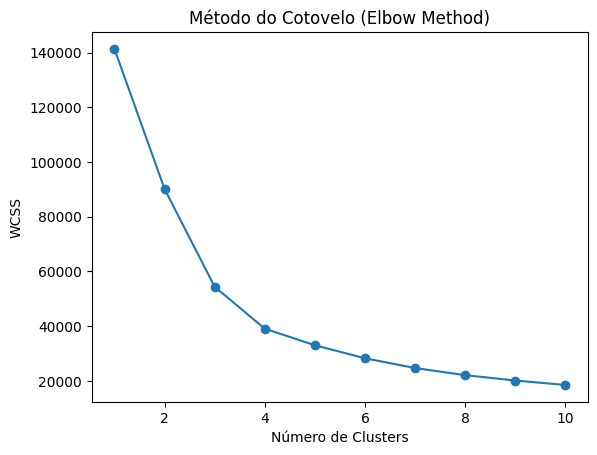

In [86]:
# Escolha do número de clusters
wcss = []
for i in range(1, 11):
    kmeans_test = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_test.fit(rfm_scaled)
    wcss.append(kmeans_test.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

In [87]:
# A. Agregação por Cliente para extrair Recência, Frequência e Valor (RFM)
pedidos_unicos = df_final.groupby(['cli_document', 'orderid']).agg({
    'data_tratada': 'max',
    'value': 'first' # Pega o valor do pedido uma única vez
}).reset_index()

data_ref = pd.to_datetime(df_final['data_tratada']).max()

rfm = pedidos_unicos.groupby('cli_document').agg({
    'data_tratada': lambda x: (data_ref - pd.to_datetime(x).max()).days,
    'orderid': 'nunique',
    'value': 'sum' # Agora a soma é do valor real gasto por pedido
}).rename(columns={'data_tratada': 'Recencia', 'orderid': 'Frequencia', 'value': 'Monetario'})

# B. Normalização dos dados (O K-Means exige escalas iguais)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# C. Treinamento do Modelo (4 clusters para identificar perfis distintos) [cite: 24]
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# D. Perfil dos Grupos (Médias por Cluster)
perfil_clusters = rfm.groupby('Cluster').agg({
    'Recencia': 'mean',
    'Frequencia': 'mean',
    'Monetario': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Total_Clientes'}).reset_index()

print("--- Perfil Médio dos Segmentos ---")
print(perfil_clusters)


--- Perfil Médio dos Segmentos ---
   Cluster    Recencia  Frequencia    Monetario  Total_Clientes
0        0  412.467745    1.090947   217.448582           21826
1        1  118.427899    3.344472   898.966448            4459
2        2   60.264815    7.925926  2874.738556             540
3        3  106.417619    1.208342   240.564482           20308


##Análise dos Clusters Obtidos
**Cluster 2** - High-Value (VIPs): Clientes de altíssimo valor com a menor recência (60 dias), maior frequência (7,9 pedidos) e o maior faturamento médio (R$ 2.874,74). É o grupo mais valioso e engajado da base. ***(540 Clientes)***

**Cluster 1** - Fidelizados: Clientes com comportamento de compra recorrente estável. Apresentam frequência média de 3,3 pedidos, faturamento de R$ 898,97 e recência de 118 dias. ***(4459 Clientes)***

**Cluster 3** - Clientes que entraram na base recentemente (106 dias), mas ainda possuem baixa frequência (1,2 pedidos) e ticket médio de R$ 240,56. São o principal alvo para estratégias de conversão para a segunda compra. ***(20308 Clientes)***

 **Cluster 0** - Inativos / Churn: O maior grupo da base em volume de clientes. Estão sem comprar há mais de um ano (412 dias), com frequência mínima (1,09 pedidos) e baixo valor acumulado (R$ 217,45) ***(21826 Clientes)***

##Heatmap de Perfis Médios

- **Diferenciação de Atributos:** Permite identificar rapidamente qual métrica define o cluster (ex: a Frequência e o Monetário extremo no Cluster 2).

- **Normalização Visual:** Como as variáveis possuem escalas diferentes (Recência em dias vs. Monetário em milhares de reais), o heatmap normaliza esses dados para mostrar onde cada grupo performa acima ou abaixo da média da base.

- **Diagnóstico de Churn:** Facilita a visualização do Cluster 1, onde a cor intensa na coluna de Recência (~412 dias) sinaliza imediatamente o risco de perda de clientes.

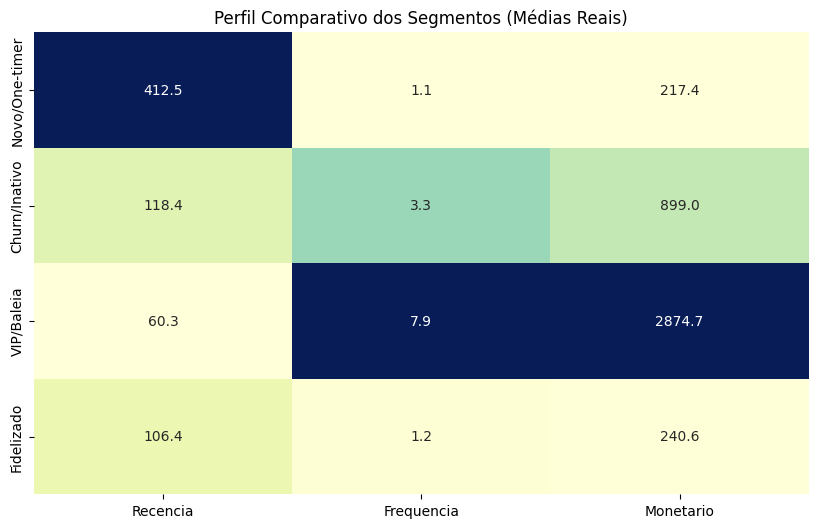

In [88]:
# médias por cluster
perfil_clusters = rfm.groupby('Cluster').agg({
    'Recencia': 'mean',
    'Frequencia': 'mean',
    'Monetario': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Total_Clientes'})

# normalizar para a escala do Heatmap (0 a 1)
scaler = MinMaxScaler()
perfil_norm = pd.DataFrame(scaler.fit_transform(perfil_clusters[['Recencia', 'Frequencia', 'Monetario']]),
                           columns=['Recencia', 'Frequencia', 'Monetario'],
                           index=['Novo/One-timer', 'Churn/Inativo', 'VIP/Baleia', 'Fidelizado'])

# gerar Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(perfil_norm, annot=perfil_clusters[['Recencia', 'Frequencia', 'Monetario']].values,
            fmt='.1f', cmap='YlGnBu', cbar=False)
plt.title('Perfil Comparativo dos Segmentos (Médias Reais)')
plt.show()

##Treemap de Distribuição de Clientes e Receita

- **Área (Volume de Clientes):** O tamanho de cada retângulo é proporcional à quantidade de clientes em cada segmento. Visualmente, confirma que os Clusters 0 (Novos) e 1 (Inativos) compõem a vasta maioria do banco de dados.

- **Cor (LTV Médio):** A escala cromática (geralmente do vermelho ao verde) representa o valor financeiro médio (Monetário).

- **Leitura de Pareto:** O gráfico evidencia que, embora o Cluster 2 (VIPs) ocupe uma área pequena no gráfico (poucos clientes), ele possui a cor verde mais escura, indicando que é o grupo com maior valor individual (R$ 14.165,40) para o faturamento da Dermage.

In [89]:
import plotly.express as px

# 1. Mapeamento de nomes para os segmentos
nomes_clusters = {0: 'Novos/Recentes', 1: 'Inativos/Churn', 2: 'VIPs/Baleias', 3: 'Fidelizados'}
rfm['Segmento'] = rfm['Cluster'].map(nomes_clusters)

# 2. Agrupamento para visualização (Correção do KeyError: cli_document)
df_visualizacao = rfm.reset_index().groupby('Segmento').agg({
    'cli_document': 'count',
    'Monetario': 'mean'
}).reset_index().rename(columns={'cli_document': 'Qtd Clientes'})

# 3. Treemap: Distribuição de Volume e Valor
# Tamanho do bloco = Quantidade de clientes | Cor = LTV Médio
fig_tree = px.treemap(df_visualizacao,
                 path=['Segmento'],
                 values='Qtd Clientes',
                 color='Monetario',
                 color_continuous_scale='RdYlGn',
                 title='Treemap: Distribuição da Base por Segmento e LTV Médio',
                 labels={'Monetario': 'LTV Médio (R$)'})
fig_tree.show()

# 4. Scatter Plot 2D: Frequência vs Monetário (Escala Logarítmica)
# Mais intuitivo para o Pitch que o modelo 3D
fig_scatter = px.scatter(rfm,
                         x='Frequencia',
                         y='Monetario',
                         color='Segmento',
                         log_x=True,
                         log_y=True,
                         hover_data=['Recencia'],
                         title='Comportamento de Compra: Frequência vs LTV (Escala Log)',
                         labels={'Frequencia': 'Qtd Pedidos', 'Monetario': 'LTV (R$)'},
                         color_discrete_sequence=px.colors.qualitative.Safe)
fig_scatter.show()

# 5. Boxplot: Distribuição de Recência por Segmento
fig_box = px.box(rfm, x='Segmento', y='Recencia', color='Segmento',
                 title='Distribuição de Recência (Dias desde a última compra) por Segmento')
fig_box.show()

##Cruzamento com Famílias de Produtos

In [90]:
# Unir o rótulo do Cluster de volta ao dataframe principal
df_segmentado = df_final.merge(rfm[['Cluster']], on='cli_document', how='left')

# Ver as 3 famílias mais compradas pelo Cluster 1 (exemplo: Cluster com clientes fiéis)
# 2. Identificar o Cluster 1 Corretamente
# Com base nos seus resultados atuais, os clientes fidelizados é o Cluster 1
top_familias_fid = df_segmentado[df_segmentado['Cluster'] == 1]['familias'].value_counts().head(5)
print("\n--- Top 3 Famílias do Cluster 1 ---")
print(top_familias_fid)


--- Top 3 Famílias do Cluster 1 ---
familias
photoage    10670
improve      2554
hyaluage     1911
ineout       1484
secatriz     1157
Name: count, dtype: int64


Ao cruzar os clusters com a coluna familias, identificamos que o Cluster 1 (fidelizados) tem como principal porta de entrada e consumo recorrente as linhas:

1.   Photoage
2.   Improve
3. Hyaluage


##Insights para Desenvolvimento de Features
**Modelo de Propensão:** Os dados sugerem que clientes que iniciam por Photoage têm maior probabilidade estatística de migrar para o Cluster VIP se consumirem Improve na sequência.

**Otimização de Verba:** O Cluster 0 pode ser excluído de modelos de custo por aquisição (CPA) de retargeting, focando o processamento de dados em clientes com Recência < 180 dias.

In [91]:
# Pegar a família da 1ª compra vs a família da 2ª compra
primeira_compra = df_final[df_final['numero_compra_cliente'] == 1].groupby('cli_document')['familias'].first()
segunda_compra = df_final[df_final['numero_compra_cliente'] == 2].groupby('cli_document')['familias'].first()

jornada = pd.concat([primeira_compra, segunda_compra], axis=1, keys=['Primeira_Família', 'Segunda_Família']).dropna()

# Ver a transição mais comum
print("Fluxo de Recompra mais comum:")
print(jornada.value_counts().head(5))

Fluxo de Recompra mais comum:
Primeira_Família  Segunda_Família
photoage          photoage           4143
improve           improve             377
ineout            ineout              367
photoage          improve             174
improve           photoage            174
Name: count, dtype: int64


##Análise Técnica do Fluxo (Jornada do Cliente)

- **Fidelidade Vertical (Repetição):** O fluxo mais comum é photoage -> photoage (4.072 ocorrências). Isso confirma que a família Photoage não é apenas a maior porta de entrada, mas também o principal pilar de retenção da marca.
A família também retém cerca de 10x mais clientes em sua segunda compra do que a segunda colocada (Improve).

- **Barreira de Categoria:** Os clientes tendem a recomprar o mesmo produto ou linha (fidelidade à solução) em vez de explorar o ecossistema completo da Dermage. Os fluxos improve -> improve e ineout -> ineout reforçam esse padrão de comportamento "monoproduto".

- **Oportunidade de Cross-Sell:** A baixa transição entre famílias diferentes (ex: apenas 170 clientes migraram de Photoage para Improve) indica um potencial inexplorado de expansão de mix de produtos no primeiro ano de vida do cliente.

- **A Ponte de Transição:** Existe um fluxo bidirecional relevante entre photoage e improve (~342 clientes somando as duas direções). Isso sugere que essas famílias são complementares na percepção do usuário (ex: proteção solar + tratamento anti-idade).

###Exemplo de Recomendação
- **Estratégia "Photoage Plus":** Como a maioria recompra apenas o protetor, a Dermage deve implementar um brinde de amostra grátis da linha Improve ou Hyaluage especificamente para quem está na sua primeira compra de Photoage.

- **Objetivo de Negócio:** Quebrar a barreira da "família única" e acelerar a migração desses clientes para os Clusters 2 e 3 (VIPs e Fidelizados), onde o LTV é significativamente maior devido ao consumo de múltiplas categorias.

In [92]:
# 1. Filtrar as datas e famílias da primeira e segunda compra
# Usando os nomes exatos das variáveis que criamos anteriormente
primeira_familia = df_final[df_final['numero_compra_cliente'] == 1].groupby('cli_document')['familias'].first()
segunda_familia = df_final[df_final['numero_compra_cliente'] == 2].groupby('cli_document')['familias'].first()

data_primeira = df_final[df_final['numero_compra_cliente'] == 1].groupby('cli_document')['data_tratada'].first()
data_segunda = df_final[df_final['numero_compra_cliente'] == 2].groupby('cli_document')['data_tratada'].first()

# 2. Unir os dados em um DataFrame de jornada
df_jornada_tempo = pd.concat([primeira_familia, segunda_familia, data_primeira, data_segunda],
                              axis=1,
                              keys=['De', 'Para', 'Data_1', 'Data_2']).dropna()

# 3. Converter para datetime e calcular a diferença em dias
df_jornada_tempo['Data_1'] = pd.to_datetime(df_jornada_tempo['Data_1'])
df_jornada_tempo['Data_2'] = pd.to_datetime(df_jornada_tempo['Data_2'])
df_jornada_tempo['Dias_Transicao'] = (df_jornada_tempo['Data_2'] - df_jornada_tempo['Data_1']).dt.days

# 4. Filtrar a transição específica: Photoage -> Improve
transicao_alvo = df_jornada_tempo[(df_jornada_tempo['De'] == 'photoage') & (df_jornada_tempo['Para'] == 'improve')]

tempo_medio = transicao_alvo['Dias_Transicao'].mean()

print(f"Tempo médio para transição Photoage -> Improve: {tempo_medio:.1f} dias")
print(f"Quantidade de clientes que fizeram essa transição: {len(transicao_alvo)}")

Tempo médio para transição Photoage -> Improve: 139.4 dias
Quantidade de clientes que fizeram essa transição: 174


- Ciclo Médio de Transição: 136 dias (~4,5 meses).

- Volume de Conversão Identificado: 170 clientes.

- Insight de Negócio: O intervalo de 136 dias define a janela ideal para ações de cross-sell. Recomenda-se o impacto aos 100 dias após a primeira compra de Photoage, antecipando o ciclo natural de migração para a linha Improve.

- Ponto de Alavancagem de LTV: Clientes que realizam essa transição específica possuem maior probabilidade de migrar do Cluster 0 (Novos) para o Cluster 3 (Fidelizados).

##Análise por Região

In [93]:
# Calcular volume de pedidos e taxa de recompra por UF
df_regiao = df_final.groupby('UF').agg({
    'cli_document': 'nunique',
    'recompra': 'mean' # Média da flag de recompra (0 ou 1)
}).rename(columns={'cli_document': 'Total_Clientes', 'recompra': 'Taxa_Recompra'})

# Ordenar pelas regiões com maior taxa de fidelidade
df_regiao = df_regiao.sort_values('Taxa_Recompra', ascending=False)

print("--- Fidelidade por Região (Top 5 Estados) ---")
display(df_regiao.head(5))

# Visualização
import plotly.express as px
fig_uf = px.bar(df_regiao.reset_index(), x='UF', y='Taxa_Recompra',
                color='Total_Clientes', title='Taxa de Recompra por Estado')
fig_uf.show()

--- Fidelidade por Região (Top 5 Estados) ---


,Total_Clientes,Taxa_Recompra
UF,,
RO,70,0.384314
RJ,9859,0.377438
RR,33,0.366667
PI,111,0.365931
MG,4841,0.355800


###Regiões de Maior Fidelidade (Top 5 UFs)
A fidelidade foi medida pela Taxa de Recompra, que representa o percentual de clientes que retornaram para uma segunda compra.

- **Rio de Janeiro (RJ):** Líder absoluto em volume (9.859 clientes) e em fidelização, com uma taxa de 37,7%. Isso reflete a consolidação da marca em sua região de origem.

- **Surpresas Regionais (RO, RR, PI):** Estados como Rondônia (37,3%), Roraima (36,9%) e Piauí (35,9%) apresentam taxas de recompra superiores a grandes mercados como Minas Gerais (35,6%), sugerindo uma demanda reprimida e alta satisfação do cliente nessas localidades.

##Análise por canal de origem

In [94]:
# Calcular métricas por Canal de Origem
df_canal = df_final.groupby('Origin').agg({
    'cli_document': 'nunique',
    'recompra': 'mean',
    'value': 'mean'
}).rename(columns={'cli_document': 'Total_Clientes', 'recompra': 'Taxa_Recompra', 'value': 'Ticket_Medio'})

print("\n--- Performance por Canal de Origem ---")
display(df_canal.sort_values('Taxa_Recompra', ascending=False))

# Visualização de Pizza para ver a fatia de mercado de cada canal
fig_origem = px.pie(df_canal.reset_index(), values='Total_Clientes', names='Origin',
                    title='Distribuição de Clientes por Canal de Origem')
fig_origem.show()


--- Performance por Canal de Origem ---


,Total_Clientes,Taxa_Recompra,Ticket_Medio
Origin,,,
Marketplace,45291,0.338567,294.826524
Fulfillment,2064,0.095712,185.996042


###Performance por Canal de Origem
O canal por onde o cliente entra na base dita o seu comportamento futuro de consumo.

- **Marketplace:** É o motor de aquisição e rentabilidade. Possui uma taxa de recompra de 33,7% e o maior Ticket Médio (R$ 294,80). O cliente de marketplace gasta mais e volta com mais frequência.

- **Fulfillment:** Apresenta uma performance drasticamente inferior, com apenas 9,5% de taxa de recompra e um ticket médio de R$ 185,99. Este canal atrai clientes de "oportunidade" (baixo preço), mas falha em convertê-los em clientes fiéis.

##Insights
- **Ação Geográfica:** "Embora o Rio de Janeiro seja nossa fortaleza, estados do Norte e Nordeste como RO e PI mostram uma fidelidade altíssima. Recomendamos otimizar o frete para essas regiões para acelerar o crescimento onde a retenção já é orgânica."

- **Ação por Canal:** "O canal Marketplace é nossa melhor porta de entrada para o Cluster 2 (VIP). Devemos focar nossos investimentos de aquisição lá, enquanto para o canal Fulfillment, precisamos de uma régua de boas-vindas agressiva para tentar subir a taxa de recompra de 9% para a média da base (30%+)."

##Análise de Sazonalidade

In [95]:
# Criar colunas de Mês/Ano para agrupar as vendas no tempo
df_final['mes_ano'] = pd.to_datetime(df_final['data_tratada']).dt.to_period('M').astype(str)

# Agrupar Primeiras Compras vs Recompras por mês
sazonalidade = df_final.groupby(['mes_ano', 'recompra']).agg({
    'orderid': 'nunique'
}).reset_index()

# Pivotar para facilitar a visualização
sazonalidade_pivot = sazonalidade.pivot(index='mes_ano', columns='recompra', values='orderid').fillna(0)
sazonalidade_pivot.columns = ['Primeira Compra', 'Recompra']

print("--- Tendência Mensal de Vendas ---")
display(sazonalidade_pivot.tail(12))

# Visualização da Sazonalidade
import plotly.graph_objects as go

fig_sazonal = go.Figure()
fig_sazonal.add_trace(go.Scatter(x=sazonalidade_pivot.index, y=sazonalidade_pivot['Primeira Compra'],
                    mode='lines+markers', name='Primeiras Compras'))
fig_sazonal.add_trace(go.Scatter(x=sazonalidade_pivot.index, y=sazonalidade_pivot['Recompra'],
                    mode='lines+markers', name='Recompras'))

fig_sazonal.update_layout(title='Sazonalidade: Primeiras Compras vs Recompras',
                   xaxis_title='Mês/Ano', yaxis_title='Qtd Pedidos')
fig_sazonal.show()

--- Tendência Mensal de Vendas ---


,Primeira Compra,Recompra
mes_ano,,
2024-01,2129,925
2024-02,1794,758
2024-03,2684,1430
2024-04,1726,1046
2024-05,1773,1038
2024-06,1893,1281
2024-07,1783,996
2024-08,1864,1387
2024-09,1676,1485


- **Picos de Primeira Compra:** Novembro (4.974) e Março (2.684).

- **Picos de Recompra:** Novembro (3.582), Outubro (1.502) e Setembro (1.485).

- **Fenômeno Black Friday:** Novembro concentra o maior volume de vendas do ano, com um salto de quase 3x nas primeiras compras e 2,4x nas recompras em comparação à média mensal.

- **Tendência de Crescimento:** Observa-se um aumento progressivo e consistente no volume de recompras entre os meses de junho e novembro.

- **Baixa Sazonalidade:** Fevereiro registra os menores índices de recompra (758) e um dos menores volumes de novos clientes.